# Dense → Mixture of Experts

**ERA V5, Session 14.** Assignment: train a linear (dense) model, convert it into an MoE, and show that it **continues to train** and that the **loss actually drops**.

Three runs, on a Colab T4:

| | Run | Tokens |
|---|---|---|
| **A** | Dense model | 15M |
| **B** | A, upcycled into an MoE, training continued | 15M more |
| **C** | The same MoE from random init — the control | 15M |

C matters. "The loss dropped after I converted it" proves nothing on its own, because more training always drops the loss. The claim only means something if the upcycled model beats the same architecture trained from scratch on the same tokens.

---

## 1. Why MoE

A normal transformer layer has one feed-forward network. Every token passes through all of it.

An MoE replaces that one FFN with several — 8 here — and adds a small **router** that picks 2 per token. The other 6 don't run. The model holds 8× the FFN weights, but each token pays for 2.

In this experiment that works out to **64.7M parameters held, 27.0M used per token**.

## 2. The parts

| Part | Role |
|---|---|
| **Router** | a `d_model × n_experts` matrix — one score per expert. Kept in **fp32**: Switch Transformer diverged when the router ran in 16-bit |
| **Score function** | `sigmoid` (each expert judged alone) or `softmax` (they compete for a fixed budget). I used sigmoid |
| **Top-k** | keep the k best scores, discard the rest. k = 2 |
| **Gates** | divide the k scores by their sum so they total 1, then scale each expert's output |
| **Shared expert** | one extra FFN, always on for every token, so the routed experts are free to specialise |

```
                     ┌──> expert 3  ──(gate 0.6)──┐
token ──> router ────┤                            ├──> add ──> out
   │                 └──> expert 7  ──(gate 0.4)──┘      │
   └───────────────────> shared expert ──────────────────┘   (always on)
```

## 3. Expert death

Gradient descent rewards a winner. An expert picked slightly more often gets trained more, so it gets better, so it gets picked more. Left alone this runs away: two experts end up doing everything while the rest never receive a token, never get a gradient, and stay at their initial values.

## 4. Load balancing without an auxiliary loss

The older fix adds a penalty term pushing usage toward `1/n_experts`. It works, but it competes with the real objective and is unstable over long runs.

The DeepSeek-V3 method used here adds nothing to the loss:

> Keep one **bias** per expert. Add it to the router's scores **when picking the top-k** — but use the *original* score for the gate. After every step: an expert that handled more tokens than average gets `bias -= γ`; one that handled fewer gets `bias += γ`. γ = 0.001.

A greedy expert is quietly made less attractive until traffic evens out, and the loss stays pure next-token prediction.

The thing to get right: the bias must affect **selection only**, never the gate value. If it leaks into the gate, the loss is being distorted again and the whole point is lost.

## 5. Why the conversion can't break training

The experts are not initialised randomly — each one is a **copy of the dense model's FFN**. If all 8 experts are identical copies of `F` and the gates sum to 1:

```
output = Σ gateᵢ · F(x) = F(x) · Σ gateᵢ = F(x) · 1 = F(x)
```

The MoE computes exactly what the dense model computed. Same output, same loss, before any training. So the loss curve cannot spike at the conversion — it continues, and then drops as the experts drift apart.

Adding a shared expert would give `F + F = 2F`, so both output projections are halved: `0.5F + Σ gateᵢ·0.5F = F`. Still exact. Part 5 checks this numerically.

---

# Part 1 — Setup

Colab T4. The model computes in 16-bit for speed, but the router and the loss stay in 32-bit.

One detail that matters on this GPU: `torch.cuda.is_bf16_supported()` returns `True` on a T4, but Turing has no bfloat16 tensor cores, so bf16 there is emulated and runs roughly 10× slower. The 16-bit type is therefore chosen by compute capability — bfloat16 only on Ampere or newer, float16 on Turing.

In [1]:
!pip -q install "datasets>=2.18" "tokenizers>=0.15" 2>/dev/null

import math, time, json, copy
from contextlib import nullcontext
from dataclasses import dataclass, replace
from pathlib import Path
import numpy as np, torch, torch.nn as nn, torch.nn.functional as F

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# Layers compute in 16-bit (fast); the router and the loss stay in 32-bit.
# bfloat16 ONLY on Ampere (capability 8.0+). On a Turing card like the T4,
# torch.cuda.is_bf16_supported() says True but bf16 there is emulated with no tensor
# cores -- about 10x slower. Turing's float16 tensor cores are fast, so use those.
USE_AMP   = True                        # the proof cells turn this off to check the maths
AMP_DTYPE = (None if DEVICE != "cuda" else
             torch.bfloat16 if torch.cuda.get_device_capability() >= (8, 0) else torch.float16)
amp = lambda: (torch.autocast("cuda", dtype=AMP_DTYPE)
               if USE_AMP and DEVICE == "cuda" else nullcontext())
up  = lambda t: t.float() if t.dtype in (torch.float16, torch.bfloat16) else t
# forces 32-bit inside an autocast region -- used for the router, which must not be 16-bit
no_amp = lambda: (torch.autocast("cuda", enabled=False) if DEVICE == "cuda" else nullcontext())

def new_scaler():                       # float16 needs a loss scaler; bfloat16 does not
    if DEVICE != "cuda" or AMP_DTYPE is not torch.float16: return None
    try: return torch.amp.GradScaler("cuda")
    except (AttributeError, TypeError): return torch.cuda.amp.GradScaler()

if DEVICE == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = True
    d = torch.cuda.get_device_properties(0)
    print(f"GPU: {d.name} | {d.total_memory/2**30:.1f} GB | 16-bit: {AMP_DTYPE}")
else:
    print("!! No GPU. Runtime -> Change runtime type -> T4 GPU")

GPU: Tesla T4 | 14.6 GB | 16-bit: torch.float16


---

# Part 2 — The feed-forward network and the MoE that replaces it

`FFN` is one ordinary feed-forward block: widen to `ff`, GELU, narrow back. The dense model has exactly one per layer; the MoE has `n_experts + 1` of them. Keeping them the same class is what makes copying weights between the two models trivial.

`MoE` is the whole routing layer — router, top-k, gates, shared expert, and the balancing bias from section 4 above.

In [2]:
class FFN(nn.Module):
    """One feed-forward network. In the dense model: the layer's only FFN.
       In the MoE: one expert (routed or shared). Same class either way."""
    def __init__(self, d_model, ff):
        super().__init__()
        self.w_in  = nn.Linear(d_model, ff, bias=False)     # widen
        self.w_out = nn.Linear(ff, d_model, bias=False)     # narrow back

    def forward(self, x):
        return self.w_out(F.gelu(self.w_in(x)))


class MoE(nn.Module):
    """
    Replaces one FFN with `n_experts` of them plus a router that picks `top_k` per token,
    and (optionally) one shared expert that every token always uses.

    Load balancing is auxiliary-loss-FREE: a per-expert bias steers the top-k choice and
    is nudged after every step. It never enters the loss and never scales an output.
    """

    def __init__(self, d_model, ff, n_experts=8, top_k=2, shared=True, score="sigmoid"):
        super().__init__()
        self.n_experts, self.top_k, self.score = n_experts, top_k, score
        self.router  = nn.Linear(d_model, n_experts, bias=False)   # kept in fp32, see below
        self.experts = nn.ModuleList(FFN(d_model, ff) for _ in range(n_experts))
        self.shared  = FFN(d_model, ff) if shared else None

        # buffers, not parameters: gradient descent must never touch these
        self.register_buffer("bal_bias", torch.zeros(n_experts))   # the balancing bias
        self.register_buffer("usage",    torch.zeros(n_experts))   # tokens seen since last update

    def forward(self, x):
        B, T, C = x.shape
        flat = x.reshape(-1, C)                                 # one row per token

        # --- the router runs in fp32 no matter what the rest of the model is doing.
        # Switch Transformer diverged when this was computed in 16-bit; it is a handful
        # of FLOPs and it decides everything, so it is not worth the risk.
        with no_amp():
            logits = self.router(up(flat))          # up() promotes 16-bit, leaves 32/64-bit alone
        scores = (torch.sigmoid(logits) if self.score == "sigmoid"
                  else torch.softmax(logits, dim=-1))

        # --- pick top_k. The balancing bias is added HERE and ONLY here: it changes WHICH
        # experts win, never HOW MUCH their output counts. That separation is the whole
        # trick -- it keeps the loss untouched.
        idx = torch.topk(scores + self.bal_bias, self.top_k, dim=-1).indices   # [tokens, k]

        # --- gates come from the ORIGINAL scores, and are normalised to sum to 1.
        # Summing to 1 is what makes the upcycled model in Part 5 exactly equal to the
        # dense one it came from.
        gates = scores.gather(-1, idx)
        gates = gates / gates.sum(-1, keepdim=True)

        # --- run each expert once, on just the tokens routed to it
        out    = torch.zeros(flat.shape, dtype=up(flat).dtype, device=flat.device)
        counts = torch.zeros(self.n_experts, device=flat.device)
        for e in range(self.n_experts):
            tok, slot = (idx == e).nonzero(as_tuple=True)       # which tokens, in which slot
            if tok.numel() == 0: continue                       # nobody chose this expert
            counts[e] = tok.numel()
            y = up(self.experts[e](flat[tok]))               # expert runs in 16-bit,
            out.index_add_(0, tok, y * gates[tok, slot, None])   # accumulate in 32-bit

        # --- the shared expert: no routing, no gate, every token
        if self.shared is not None:
            out = out + up(self.shared(flat))

        if self.training:
            self.usage += counts                                # remember for the bias update
        return out.reshape(B, T, C).to(x.dtype)

    @torch.no_grad()
    def rebalance(self, gamma=1e-3):
        """
        DeepSeek-V3 loss-free balancing, run once per optimizer step.
        Busier than average -> make this expert less attractive. Quieter -> more attractive.
        torch.sign gives exactly the -gamma / +gamma rule.
        """
        if self.usage.sum() == 0: return
        target = self.usage.sum() / self.n_experts       # what perfectly even traffic looks like
        self.bal_bias += gamma * torch.sign(target - self.usage)
        self.usage.zero_()

    @torch.no_grad()
    def usage_fraction(self):
        """Share of tokens each expert received since the last reset (for the plots)."""
        tot = self.usage.sum()
        return (self.usage / tot) if tot > 0 else self.usage.clone()

---

# Part 3 — The model

One class covers both models. `n_experts = 0` gives the dense ("linear") model, where each layer's feed-forward slot holds a single `FFN`. Any higher value puts a `MoE` there instead. Embeddings, attention, norms and the output head are identical in both, which is what lets the weights be copied straight across.

`n_params()` returns **(total, active-per-token)**. For the dense model these are equal; for the MoE the gap between them is the entire point.

In [3]:
@dataclass
class Config:
    vocab: int = 8192; layers: int = 8; d_model: int = 384; heads: int = 6
    ff: int = 1024;    ctx: int = 512
    n_experts: int = 0        # 0 = dense model. >0 = MoE with this many routed experts
    top_k: int = 2            # how many routed experts each token uses
    shared: bool = True       # the always-on expert
    score: str = "sigmoid"    # router score function: "sigmoid" or "softmax"


class Block(nn.Module):
    """Standard pre-LN transformer layer. The only thing that varies is what sits
       in the feed-forward slot: one FFN (dense) or a whole MoE."""
    def __init__(self, cfg):
        super().__init__()
        self.heads = cfg.heads
        self.ln1, self.ln2 = nn.LayerNorm(cfg.d_model), nn.LayerNorm(cfg.d_model)
        self.qkv  = nn.Linear(cfg.d_model, 3 * cfg.d_model, bias=False)
        self.proj = nn.Linear(cfg.d_model, cfg.d_model, bias=False)
        self.ffn  = (FFN(cfg.d_model, cfg.ff) if cfg.n_experts == 0 else
                     MoE(cfg.d_model, cfg.ff, cfg.n_experts, cfg.top_k, cfg.shared, cfg.score))

    def attention(self, x):
        B, T, C = x.shape
        q, k, v = self.qkv(x).split(C, dim=2)
        q, k, v = (t.view(B, T, self.heads, C // self.heads).transpose(1, 2) for t in (q, k, v))
        y = F.scaled_dot_product_attention(q, k, v, is_causal=True)   # each word sees only earlier ones
        return self.proj(y.transpose(1, 2).reshape(B, T, C))

    def forward(self, x):
        x = x + self.attention(self.ln1(x))
        return x + self.ffn(self.ln2(x))


class TinyGPT(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.cfg = cfg
        self.tok = nn.Embedding(cfg.vocab, cfg.d_model)       # token    -> vector
        self.pos = nn.Embedding(cfg.ctx,   cfg.d_model)       # position -> vector
        self.blocks = nn.ModuleList(Block(cfg) for _ in range(cfg.layers))
        self.ln_f = nn.LayerNorm(cfg.d_model)
        self.head = nn.Linear(cfg.d_model, cfg.vocab, bias=False)
        self.head.weight = self.tok.weight                    # shared, saves memory
        self.apply(lambda m: nn.init.normal_(m.weight, std=0.02)
                   if isinstance(m, (nn.Linear, nn.Embedding)) else None)

    def moe_layers(self):
        return [b.ffn for b in self.blocks if isinstance(b.ffn, MoE)]

    def n_params(self):
        """(total, active-per-token). For a dense model these are equal. For an MoE the
           gap between them IS the point: many weights, few used per token."""
        total = sum(p.numel() for p in self.parameters())
        moes = self.moe_layers()
        if not moes: return total, total
        skipped = 0
        for m in moes:                                        # experts NOT run for a token
            per_expert = sum(p.numel() for p in m.experts[0].parameters())
            skipped += per_expert * (m.n_experts - m.top_k)
        return total, total - skipped

    def forward(self, ids, targets=None):
        with amp():
            x = self.tok(ids) + self.pos(torch.arange(ids.shape[1], device=ids.device))
            for block in self.blocks:
                x = block(x)
            logits = self.head(self.ln_f(x))
        if targets is None: return logits, None
        return logits, F.cross_entropy(up(logits).reshape(-1, logits.shape[-1]), targets.reshape(-1))


print("model defined")

model defined


---

# Part 4 — Upcycling: dense → MoE

Four steps:

1. Build an empty MoE with the same embedding / attention / norm / head shapes.
2. Copy everything that isn't the feed-forward slot straight across — unchanged.
3. Copy the dense `FFN` into every routed expert and into the shared expert.
4. Initialise the router small and random, and give each expert's balancing bias a speck of noise so ties break differently and the experts start to diverge.

Then the scale fix. With a shared expert the layer would compute `F + F = 2F`, so `w_out` is halved on the shared expert and on every routed expert:

```
0.5·F(x)  +  Σ gateᵢ · 0.5·F(x)   =   0.5·F(x) + 0.5·F(x)   =   F(x)
 shared         routed, gates sum to 1
```

Without a shared expert there is nothing to halve and `scale = 1.0`.

In [4]:
def upcycle(dense, n_experts=8, top_k=2, shared=True, router_std=0.02, bias_noise=1e-3):
    """Turn a trained dense model into an MoE that computes exactly the same function."""
    cfg = replace(dense.cfg, n_experts=n_experts, top_k=top_k, shared=shared)
    moe = TinyGPT(cfg).to(next(dense.parameters()).device)

    # 1-2. everything that is not the FFN carries over untouched
    moe.load_state_dict(dense.state_dict(), strict=False)

    # with a shared expert we would compute F twice, so halve both halves
    scale = 0.5 if shared else 1.0

    for dense_block, moe_block in zip(dense.blocks, moe.blocks):
        src, dst = dense_block.ffn, moe_block.ffn             # FFN -> MoE
        for expert in list(dst.experts) + ([dst.shared] if shared else []):
            expert.w_in.weight.data.copy_(src.w_in.weight.data)          # 3. identical copy
            expert.w_out.weight.data.copy_(src.w_out.weight.data * scale)
        # 4. router starts small and undecided; the bias noise breaks symmetry so the
        #    experts get different token mixes and begin to diverge from each other
        dst.router.weight.data.normal_(0, router_std)
        dst.bal_bias.normal_(0, bias_noise)

    return moe


print("upcycle defined")

upcycle defined


---

# Part 5 — Checking the conversion before spending GPU time

Two checks, in float64 with mixed precision off so this tests the arithmetic rather than 16-bit rounding:

1. **Same output.** The upcycled MoE and the dense model it came from must produce identical logits and identical loss on the same input.
2. **Same output no matter what the router does.** Scramble the router and check again. Since every expert is an identical copy, *which* two get chosen cannot matter. If this one fails, the gates are not summing to 1.

Four configurations are tested, with and without a shared expert.

In [5]:
USE_AMP = False
torch.manual_seed(0)

small = Config(vocab=512, layers=4, d_model=128, heads=4, ff=256, ctx=64)
dense = TinyGPT(small).double()
ids   = torch.randint(0, 512, (2, 64))
tgts  = torch.randint(0, 512, (2, 64))

print("PROOF -- does upcycling preserve the function?\n")
for n_exp, k, sh in [(4, 1, False), (8, 2, False), (8, 2, True), (16, 4, True)]:
    moe = upcycle(dense, n_experts=n_exp, top_k=k, shared=sh).double()

    lo_d, loss_d = dense(ids, tgts)
    lo_m, loss_m = moe(ids, tgts)
    err = (lo_d - lo_m).abs().max().item() / lo_d.abs().max().item()

    # and again with a completely different router -- the choice must not matter
    for m in moe.moe_layers(): m.router.weight.data.normal_(0, 1.0)
    _, loss_r = moe(ids, tgts)

    tot, act = moe.n_params()
    print(f"  {n_exp:>2} experts, top-{k}, shared={str(sh):<5} "
          f"logit error {err:.1e}  |  loss {loss_d.item():.6f} -> {loss_m.item():.6f} "
          f"| random router {loss_r.item():.6f}  {'PASS' if err < 1e-12 else 'FAIL'}")
    print(f"      params  dense {dense.n_params()[0]/1e6:.2f}M  ->  MoE total {tot/1e6:.2f}M, "
          f"active per token {act/1e6:.2f}M\n")

USE_AMP = True
print("Identical output, and unchanged when the router is scrambled.")
print("So the loss cannot spike at conversion -- training must continue from where it stopped.")

PROOF -- does upcycling preserve the function?

   4 experts, top-1, shared=False logit error 0.0e+00  |  loss 6.249866 -> 6.249866 | random router 6.249866  PASS
      params  dense 0.60M  ->  MoE total 1.39M, active per token 0.60M

   8 experts, top-2, shared=False logit error 7.7e-16  |  loss 6.249866 -> 6.249866 | random router 6.249866  PASS
      params  dense 0.60M  ->  MoE total 2.44M, active per token 0.87M

   8 experts, top-2, shared=True  logit error 7.2e-16  |  loss 6.249866 -> 6.249866 | random router 6.249866  PASS
      params  dense 0.60M  ->  MoE total 2.70M, active per token 1.13M

  16 experts, top-4, shared=True  logit error 7.2e-16  |  loss 6.249866 -> 6.249866 | random router 6.249866  PASS
      params  dense 0.60M  ->  MoE total 4.80M, active per token 1.66M

Identical output, and unchanged when the router is scrambled.
So the loss cannot spike at conversion -- training must continue from where it stopped.


---

# Part 6 — Data

**AI4Bharat Sangraha** (`verified` split), six Indian languages: Hindi 30%, Telugu 25%, Tamil 15%, Marathi 10%, Bengali 10%, English 10%. 35M tokens pooled, 1M held out.

The tokenizer is my own **8192-piece byte-level BPE**, trained on the same mix. Byte-level matters here: it works on raw bytes, so Devanagari, Telugu, Tamil, Bengali and Latin all encode without ever producing an unknown token.

Documents are shuffled whole before splitting, so the six languages interleave rather than sitting in six blocks.

In [6]:
MIX = {"hin": .30, "tel": .25, "tam": .15, "mar": .10, "ben": .10, "eng": .10}
TOKENS, VAL_TOKENS, VOCAB = 35_000_000, 1_000_000, 8192   # TOKENS = 4_000_000 for a trial
DATA = Path("data"); DATA.mkdir(exist_ok=True); EOT = "<|endoftext|>"

from datasets import load_dataset
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers, processors


def download(lang, want_bytes):
    """Stream one Sangraha language until `want_bytes` of text is on disk."""
    path = DATA / f"raw_{lang}.txt"
    if path.exists() and path.stat().st_size >= want_bytes * .98:
        print(f"  {lang}: cached"); return path
    t0, n = time.time(), 0
    with open(path, "w", encoding="utf-8") as f:
        for rec in load_dataset("ai4bharat/sangraha", "verified", split=lang, streaming=True):
            text = (rec.get("text") or "").strip()
            if len(text) < 200: continue                       # skip near-empty scraps
            f.write(text + "\n" + EOT + "\n"); n += len(text.encode()) + 16
            if n >= want_bytes: break
    print(f"  {lang}: {n/1e6:5.0f} MB ({time.time()-t0:.0f}s)"); return path


def build_dataset():
    meta = DATA / "meta.json"
    if meta.exists() and json.loads(meta.read_text())["train_tokens"] >= TOKENS * .97:
        print("Dataset cached."); return json.loads(meta.read_text())

    # ~5 bytes per token is a generous guess for Indic scripts; we trim to the exact budget below
    print("Step 1/3 -- downloading (~250 MB, 8-12 min)")
    files = {l: download(l, int((TOKENS + VAL_TOKENS) * share * 5)) for l, share in MIX.items()}

    print("\nStep 2/3 -- training an 8192-piece byte-level tokenizer")
    tok = Tokenizer(models.BPE(unk_token=None))
    tok.pre_tokenizer, tok.decoder = pre_tokenizers.ByteLevel(add_prefix_space=False), decoders.ByteLevel()
    tok.post_processor = processors.ByteLevel(trim_offsets=False)
    def sample():                                              # 10 MB per language is plenty
        for path in files.values():
            used = 0
            for line in open(path, encoding="utf-8"):
                if line.strip() != EOT: yield line; used += len(line)
                if used > 10_000_000: break
    tok.train_from_iterator(sample(), trainer=trainers.BpeTrainer(
        vocab_size=VOCAB, special_tokens=[EOT], show_progress=False,
        initial_alphabet=pre_tokenizers.ByteLevel.alphabet()))     # all 256 bytes -> never <unk>
    tok.save(str(DATA / f"bpe_{VOCAB}.json")); eot = tok.token_to_id(EOT)

    print("\nStep 3/3 -- turning text into numbers")
    pieces, stats = [], {}
    for lang, path in files.items():
        docs = [d for d in open(path, encoding="utf-8").read().split(EOT) if d.strip()]
        arr = np.concatenate([np.array(e.ids + [eot], dtype=np.uint16)
                              for i in range(0, len(docs), 2000)
                              for e in tok.encode_batch(docs[i:i + 2000])])
        stats[lang] = {"tokens": int(len(arr)),
                       "bytes_per_token": round(sum(len(d.encode()) for d in docs) / len(arr), 2)}
        pieces.append(arr)
        print(f"  {lang}: {len(arr)/1e6:5.2f}M tokens, {stats[lang]['bytes_per_token']} bytes/token")

    ids = np.concatenate(pieces)
    docs = np.split(ids, (np.flatnonzero(ids == eot) + 1)[:-1])    # shuffle whole documents so
    np.random.default_rng(1337).shuffle(docs)                      # the six languages interleave
    ids = np.concatenate(docs)[:TOKENS + VAL_TOKENS]
    ids[:VAL_TOKENS].tofile(DATA / "val.bin"); ids[VAL_TOKENS:].tofile(DATA / "train.bin")

    out = {"vocab": VOCAB, "train_tokens": int(len(ids) - VAL_TOKENS), "per_language": stats}
    meta.write_text(json.dumps(out, indent=2))
    print(f"\nReady: {out['train_tokens']/1e6:.1f}M training tokens, {VAL_TOKENS/1e6:.1f}M held out")
    return out


META = build_dataset()

Step 1/3 -- downloading (~250 MB, 8-12 min)


README.md:   0%|          | 0.00/10.9k [00:00<?, ?B/s]

Resolving data files:   0%|          | 0/77 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/50 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

...

Resolving data files:   0%|          | 0/25 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/53 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/41 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/27 [00:00<?, ?it/s]

  eng:    18 MB (17s)

Step 2/3 -- training an 8192-piece byte-level tokenizer

Step 3/3 -- turning text into numbers
  hin: 13.87M tokens, 3.88 bytes/token
  tel: 12.60M tokens, 3.56 bytes/token
  tam:  7.43M tokens, 3.63 bytes/token
  mar:  4.84M tokens, 3.71 bytes/token
  ben:  4.82M tokens, 3.73 bytes/token
  eng:  5.34M tokens, 3.36 bytes/token

Ready: 35.0M training tokens, 1.0M held out


---

# Part 7 — Training loop

An ordinary loop. Two extra lines for the MoE, both after `opt.step()`:

* accumulate `usage` — how many tokens each expert handled, used later to check none died;
* call `rebalance(γ)` — the bias nudge from section 4.

There is no auxiliary loss term anywhere. The loss is pure next-token prediction.

`token_offset` lets run B's x-axis continue where run A's stopped, and `smooth0` carries the running loss average across the conversion. The second one is only legitimate because the upcycled model computes the identical function — without it the curve appears to jump purely because a fresh average starts from nothing.

In [7]:
class Batches:
    """Hands out random chunks of text from a .bin file."""
    def __init__(self, path, ctx, seed=1234):
        self.data, self.ctx = np.fromfile(path, dtype=np.uint16), ctx    # ~70 MB, keep in RAM
        self.rng = np.random.default_rng(seed)

    def get(self, n):
        s = self.rng.integers(0, len(self.data) - self.ctx - 1, size=n)
        grab = lambda off: torch.from_numpy(np.stack(
            [self.data[i + off: i + off + self.ctx].astype(np.int64) for i in s])).to(DEVICE)
        return grab(0), grab(1)                       # inputs, and the same shifted by one


def train_run(label, model, tokens, batch=32, lr=3e-4, gamma=1e-3, token_offset=0,
              smooth0=None, log_every=100):
    """Train `model` on `tokens` tokens. Returns (model, measurements)."""
    torch.manual_seed(1337)
    ctx      = model.cfg.ctx
    per_step = batch * ctx
    steps    = max(1, tokens // per_step)
    warmup   = min(200, steps // 10 + 1)
    scaler   = new_scaler()
    opt = torch.optim.AdamW(model.parameters(), lr=lr, betas=(.9, .95),
                            weight_decay=0.1, fused=(DEVICE == "cuda"))
    train, val = Batches(DATA / "train.bin", ctx), Batches(DATA / "val.bin", ctx, seed=7)
    moes = model.moe_layers()
    usage_total = torch.zeros(moes[0].n_experts) if moes else None

    total, active = model.n_params()
    print(f"\n{'='*72}\n{label}   {total/1e6:.1f}M params, {active/1e6:.1f}M active per token"
          f"\n{steps:,} steps x {per_step:,} tokens = {steps*per_step/1e6:.1f}M tokens", flush=True)
    if DEVICE == "cuda": torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats()

    # smooth0 carries the previous run's loss average across a conversion. Legitimate here:
    # the upcycled model computes the identical function, so the average has not gone stale.
    # Without it the curve appears to jump, purely because a fresh average starts from zero.
    history, smooth, t0 = [], smooth0, time.time()
    model.train()
    for step in range(steps):
        frac = (step - warmup) / max(steps - warmup, 1)          # warm up, then cosine to 10%
        for g in opt.param_groups:
            g["lr"] = lr * ((step + 1) / warmup if step < warmup
                            else .1 + .45 * (1 + math.cos(math.pi * frac)))

        _, loss = model(*train.get(batch))
        opt.zero_grad(set_to_none=True)
        (scaler.scale(loss) if scaler else loss).backward()
        if scaler: scaler.unscale_(opt)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        if scaler:
            scaler.step(opt); scaler.update()
        else:
            opt.step()

        # ---- the only MoE-specific lines in the whole loop ----------------------------
        for m in moes:
            usage_total += m.usage.detach().float().cpu()        # for the "nobody died" plot
            m.rebalance(gamma)                                   # loss-free bias nudge
        # ------------------------------------------------------------------------------

        smooth = loss.item() if smooth is None else .95 * smooth + .05 * loss.item()
        if step < 3 or (step + 1) % log_every == 0 or step == steps - 1:
            rate = (step + 1) * per_step / (time.time() - t0)
            history.append({"tokens": token_offset + (step + 1) * per_step, "loss": round(smooth, 4)})
            print(f"  step {step+1:>5}/{steps}  loss {smooth:6.3f}  {rate:>8,.0f} tok/s"
                  f"  eta {(steps-step-1)*per_step/rate/60:5.1f} min", flush=True)

    if DEVICE == "cuda": torch.cuda.synchronize()
    secs = time.time() - t0
    model.eval()
    with torch.no_grad():
        vl = sum(model(*val.get(8))[1].item() for _ in range(20)) / 20
    model.train()

    share = (usage_total / usage_total.sum()).tolist() if moes else None
    r = {"label": label, "tokens": steps * per_step, "steps": steps, "lr": lr,
         "params_total": total, "params_active": active,
         "train_loss": round(smooth, 4), "val_loss": round(vl, 4),
         "perplexity": round(math.exp(min(vl, 20)), 1),
         "tokens_per_sec": round(steps * per_step / secs), "minutes": round(secs / 60, 1),
         "peak_memory_mb": round(torch.cuda.max_memory_allocated() / 2**20, 1)
                           if DEVICE == "cuda" else float("nan"),
         "expert_share": share, "history": history}
    Path(f"run_{label.split()[0].lower()}.json").write_text(json.dumps(r, indent=2))
    print(f"  FINAL  val loss {r['val_loss']:.4f}  |  {r['tokens_per_sec']:,} tok/s"
          f"  |  peak {r['peak_memory_mb']:,.0f} MB  |  {secs/60:.1f} min", flush=True)
    if share:
        ideal = 1 / len(share)
        print(f"         expert load: min {min(share)*100:4.1f}%  max {max(share)*100:4.1f}%"
              f"  (perfectly even would be {ideal*100:.1f}%)  dead experts: "
              f"{sum(1 for s in share if s < 0.01*ideal)}", flush=True)
    return model, r

---

# Part 8 — The three runs

Dense model: 8 layers, 384 wide, 1024 feed-forward. MoE: 8 routed experts, top-2, plus one shared expert, γ = 0.001.

Runs B and C use the same learning rate and schedule, so the only difference between them is where the weights came from.

Before run B starts, the conversion is checked once more on real tokens rather than random ones.

In [8]:
DENSE_TOKENS, MOE_TOKENS = 15_000_000, 15_000_000
N_EXPERTS, TOP_K, SHARED, GAMMA = 8, 2, True, 1e-3
MOE_LR = 2e-4

dense_cfg = Config(vocab=META["vocab"], layers=8, d_model=384, heads=6, ff=1024, ctx=512)
results = {}

# ---- A: the dense "linear" model ------------------------------------------------------
dense, results["dense"] = train_run("A dense", TinyGPT(dense_cfg).to(DEVICE),
                                    DENSE_TOKENS, lr=3e-4)

# ---- B: upcycle it, then keep going ---------------------------------------------------
moe = upcycle(dense, n_experts=N_EXPERTS, top_k=TOP_K, shared=SHARED)
with torch.no_grad():                      # sanity check the conversion on real data
    b = Batches(DATA / "train.bin", dense_cfg.ctx); x, y = b.get(8)
    dense.eval(); moe.eval()
    gap = abs(dense(x, y)[1].item() - moe(x, y)[1].item())
    dense.train(); moe.train()
print(f"\nconversion check on real tokens: dense loss vs MoE loss differ by {gap:.2e}")

_, results["upcycled"] = train_run("B upcycled MoE", moe, MOE_TOKENS, lr=MOE_LR, gamma=GAMMA,
                                   token_offset=DENSE_TOKENS,
                                   smooth0=results["dense"]["train_loss"])

# ---- C: the control -- same MoE, random weights ---------------------------------------
scratch_cfg = replace(dense_cfg, n_experts=N_EXPERTS, top_k=TOP_K, shared=SHARED)
_, results["scratch"] = train_run("C MoE from scratch", TinyGPT(scratch_cfg).to(DEVICE),
                                  MOE_TOKENS, lr=MOE_LR, gamma=GAMMA, token_offset=DENSE_TOKENS)

json.dump(results, open("results.json", "w"), indent=2)
print("\nsaved results.json")


A dense   14.4M params, 14.4M active per token
915 steps x 16,384 tokens = 15.0M tokens
  step     1/915  loss  9.072    17,805 tok/s  eta  14.0 min
  step     2/915  loss  9.070    30,512 tok/s  eta   8.2 min
  step     3/915  loss  9.068    40,172 tok/s  eta   6.2 min
  step   100/915  loss  5.264   102,180 tok/s  eta   2.2 min
  step   200/915  loss  4.169   101,997 tok/s  eta   1.9 min
  step   300/915  loss  3.889    99,749 tok/s  eta   1.7 min
  step   400/915  loss  3.816    96,733 tok/s  eta   1.5 min
  step   500/915  loss  3.763    93,828 tok/s  eta   1.2 min
  step   600/915  loss  3.749    93,006 tok/s  eta   0.9 min
  step   700/915  loss  3.651    92,789 tok/s  eta   0.6 min
  step   800/915  loss  3.652    92,460 tok/s  eta   0.3 min
  step   900/915  loss  3.650    91,980 tok/s  eta   0.0 min
  step   915/915  loss  3.607    91,909 tok/s  eta   0.0 min
  FINAL  val loss 3.7051  |  91,908 tok/s  |  peak 3,516 MB  |  2.7 min

conversion check on real tokens: dense loss v

---

# Part 9 — Results

The table, then three plots: the join at the conversion, the comparison against starting over, and the expert load distribution.

In [9]:
a, b, c = results["dense"], results["upcycled"], results["scratch"]

print(f"{'run':<22}{'total':>9}{'active':>9}{'val loss':>10}{'ppl':>8}{'tok/s':>10}{'peak MB':>10}{'min':>7}")
for r in (a, b, c):
    print(f"{r['label']:<22}{r['params_total']/1e6:>8.1f}M{r['params_active']/1e6:>8.1f}M"
          f"{r['val_loss']:>10.4f}{r['perplexity']:>8.1f}{r['tokens_per_sec']:>10,}"
          f"{r['peak_memory_mb']:>10,.0f}{r['minutes']:>7.1f}")

share = b["expert_share"]; ideal = 1 / len(share)
print(f"""
{'='*76}
1. DID IT CONTINUE?     dense finished at {a['val_loss']:.4f},
                        the upcycled MoE started from the identical function
                        and finished at {b['val_loss']:.4f}   ({b['val_loss']-a['val_loss']:+.4f})

2. DID THE LOSS DROP?   {a['val_loss']:.4f} -> {b['val_loss']:.4f}   \
({100*(a['val_loss']-b['val_loss'])/a['val_loss']:.1f}% lower)
                        perplexity {a['perplexity']:.1f} -> {b['perplexity']:.1f}

3. WAS UPCYCLING WORTH IT?
                        upcycled {b['val_loss']:.4f}  vs  from scratch {c['val_loss']:.4f}
                        the same MoE, same tokens, same LR -- only the starting weights differ
                        gap: {c['val_loss']-b['val_loss']:+.4f}

4. DID ANY EXPERT DIE?  busiest {max(share)*100:.1f}%, quietest {min(share)*100:.1f}%, \
even would be {ideal*100:.1f}%
                        dead (under 1% of even): {sum(1 for s in share if s < .01*ideal)} of {len(share)}
                        achieved with NO auxiliary loss -- only the bias nudge

5. THE MoE BARGAIN      {b['params_total']/1e6:.1f}M parameters held, \
{b['params_active']/1e6:.1f}M used per token \
({b['params_total']/b['params_active']:.1f}x more knowledge than compute)
{'='*76}""")

run                       total   active  val loss     ppl     tok/s   peak MB    min
A dense                   14.4M    14.4M    3.7051    40.7    91,908     3,516    2.7
B upcycled MoE            64.7M    27.0M    3.4114    30.3    44,792     6,557    5.6
C MoE from scratch        64.7M    27.0M    3.7272    41.6    45,049     7,089    5.5

1. DID IT CONTINUE?     dense finished at 3.7051,
                        the upcycled MoE started from the identical function
                        and finished at 3.4114   (-0.2937)

2. DID THE LOSS DROP?   3.7051 -> 3.4114   (7.9% lower)
                        perplexity 40.7 -> 30.3

3. WAS UPCYCLING WORTH IT?
                        upcycled 3.4114  vs  from scratch 3.7272
                        the same MoE, same tokens, same LR -- only the starting weights differ
                        gap: +0.3158

4. DID ANY EXPERT DIE?  busiest 12.6%, quietest 12.4%, even would be 12.5%
                        dead (under 1% of even): 0 of 8
       

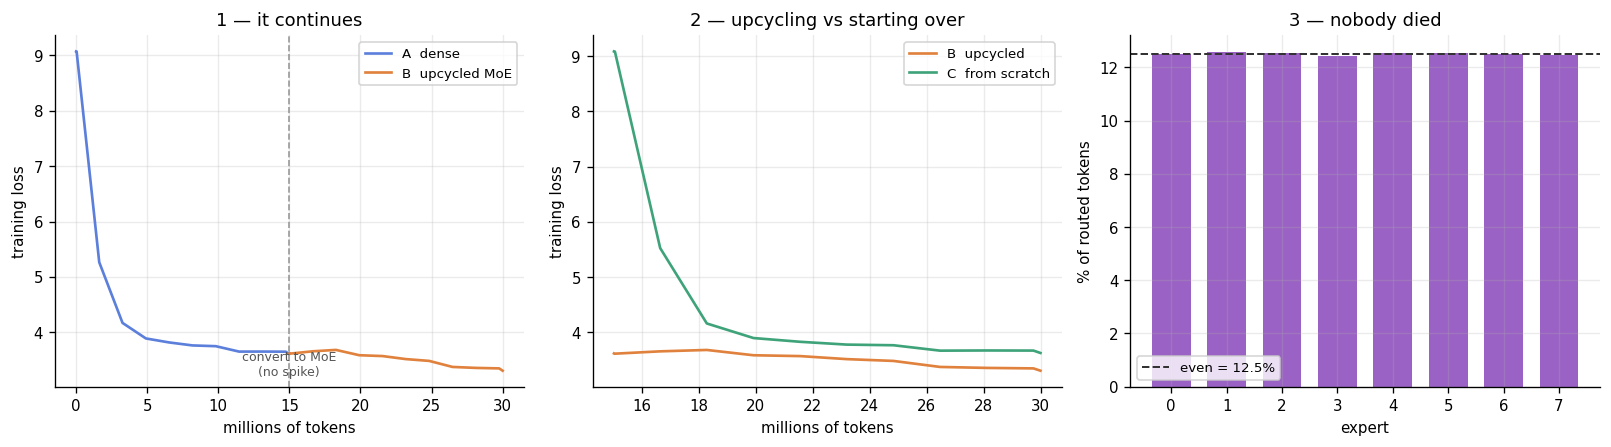

saved results.png


In [10]:
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.dpi": 120, "font.size": 9, "axes.grid": True, "grid.alpha": .25,
                     "axes.spines.top": False, "axes.spines.right": False})
fig, ax = plt.subplots(1, 3, figsize=(13.5, 3.8))

# 1: the join -- dense then upcycled, one continuous line
for r, col, lab in [(a, "#5B7FDB", "A  dense"), (b, "#E0823D", "B  upcycled MoE")]:
    ax[0].plot([h["tokens"]/1e6 for h in r["history"]], [h["loss"] for h in r["history"]],
               color=col, lw=1.6, label=lab)
ax[0].axvline(a["tokens"]/1e6, color="#999", ls="--", lw=1)
ax[0].annotate("convert to MoE\n(no spike)", (a["tokens"]/1e6, max(h["loss"] for h in b["history"])),
               fontsize=7.5, ha="center", va="top", color="#555")
ax[0].set(xlabel="millions of tokens", ylabel="training loss", title="1 — it continues")
ax[0].legend(fontsize=8)

# 2: upcycled vs from scratch, over the same token window
for r, col, lab in [(b, "#E0823D", "B  upcycled"), (c, "#3FA37A", "C  from scratch")]:
    ax[1].plot([h["tokens"]/1e6 for h in r["history"]], [h["loss"] for h in r["history"]],
               color=col, lw=1.6, label=lab)
ax[1].set(xlabel="millions of tokens", ylabel="training loss", title="2 — upcycling vs starting over")
ax[1].legend(fontsize=8)

# 3: expert load -- the proof that nothing died
x = range(len(share))
ax[2].bar(x, [s*100 for s in share], color="#9A62C4", width=.7)
ax[2].axhline(ideal*100, color="#333", ls="--", lw=1.2, label=f"even = {ideal*100:.1f}%")
ax[2].set(xlabel="expert", ylabel="% of routed tokens", title="3 — nobody died", xticks=list(x))
ax[2].legend(fontsize=8)

fig.tight_layout(); fig.savefig("results.png", dpi=150); plt.show()
print("saved results.png")